In [1]:
import pandas as pd
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','attack_class'
]

In [2]:
df = pd.read_csv('data/KDDTest+.txt', names=column_names)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Checking skewness before log transformation
print("----- Skewness Before Log Transformation -----")
print("duration skewness:", df['duration'].skew())
print("src_bytes skewness:", df['src_bytes'].skew())
print("dst_bytes skewness:", df['dst_bytes'].skew())

----- Skewness Before Log Transformation -----
duration skewness: 47.50250475223825
src_bytes skewness: 63.45658244705127
dst_bytes skewness: 7.739911057936902


In [8]:
#Applying Log Transformation
df_log = df.copy()
df_log['duration_log'] = np.log1p(df['duration'])
df_log['src_bytes_log'] = np.log1p(df['src_bytes'])
df_log['dst_bytes_log'] = np.log1p(df['dst_bytes'])

In [5]:
# Checking skewness after log transformation
print("\n----- Skewness After Log Transformation -----")
print("duration_log skewness:", df_log['duration_log'].skew())
print("src_bytes_log skewness:", df_log['src_bytes_log'].skew())
print("dst_bytes_log skewness:", df_log['dst_bytes_log'].skew())


----- Skewness After Log Transformation -----
duration_log skewness: 0.21943214294360386
src_bytes_log skewness: 5.308927887290868
dst_bytes_log skewness: 6.831356711538509


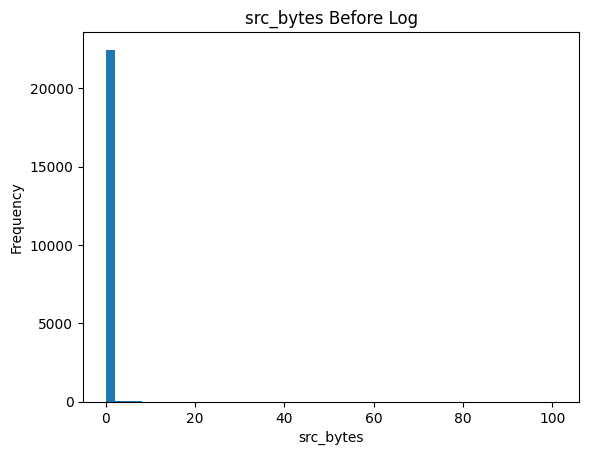

In [6]:
#Visualization before log transformation
plt.figure()
plt.hist(df['src_bytes'], bins=50)
plt.title("src_bytes Before Log")
plt.xlabel("src_bytes")
plt.ylabel("Frequency")
plt.show()

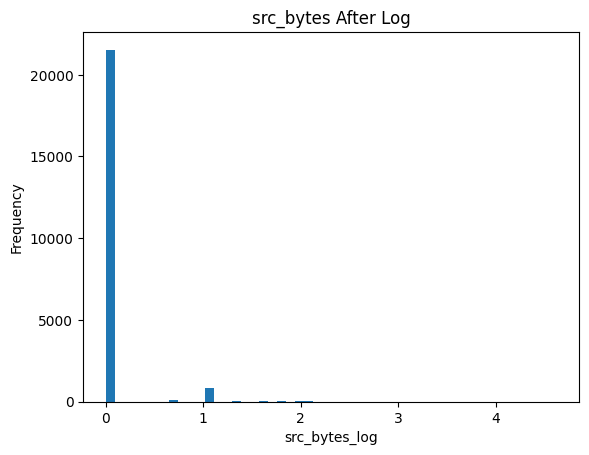

In [9]:
#Visualization after log transformation
plt.figure()
plt.hist(df_log['src_bytes_log'], bins=50)
plt.title("src_bytes After Log")
plt.xlabel("src_bytes_log")
plt.ylabel("Frequency")
plt.show()

In [10]:
#Separate X and y
X = df.drop("attack_class", axis=1)   #for features
y = df["attack_class"]                #for target

In [11]:
#Keep only numeric columns
X = X.select_dtypes(include=[np.number])
print("Numeric features shape:", X.shape)

Numeric features shape: (22544, 36)


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [13]:
from sklearn.feature_selection import VarianceThreshold
# Remove useless low-change features
var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X)
var_cols = X.columns[var_selector.get_support()]
X_var = pd.DataFrame(X_var, columns=var_cols)
print("After removing low variance:", X_var.shape)

After removing low variance: (22544, 27)


In [14]:
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_uncorr = X_var.drop(columns=to_drop)
print("Removed correlated:", len(to_drop))
print("After correlation removal:", X_uncorr.shape)

Removed correlated: 7
After correlation removal: (22544, 20)


In [15]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_uncorr, y_encoded)
mi_series = pd.Series(mi_scores, index=X_uncorr.columns)
mi_series = mi_series.sort_values(ascending=False)
selected_features = mi_series[mi_series > 0.01].index
X_selected = X_uncorr[selected_features]
print("After MI:", X_selected.shape)

After MI: (22544, 18)


In [16]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(model, n_features_to_select=15)
X_rfe = rfe.fit_transform(X_selected, y_encoded)
final_cols = X_selected.columns[rfe.support_]
X_final = pd.DataFrame(X_rfe, columns=final_cols)
print("After RFE:", X_final.shape)

After RFE: (22544, 15)


In [17]:
final_df = pd.concat([X_final, y.reset_index(drop=True)], axis=1)
print("Final shape:", final_df.shape)

Final shape: (22544, 16)


In [18]:
final_df.to_csv("../SentinelNet/data/processed/train_feature_selected.csv", index=False)